# نوت‌بوک مستقل HMDA — Feature Engineering V2

این نوت‌بوک کل مسیر پروژه را بدون import از `src/` یا `scripts/` بازسازی می‌کند: قرارداد داده، پاک‌سازی، EDA، split، مهندسی ویژگی V2، Mutual Information، سه راهبرد عدم‌توازن، ۹ مدل کلاسیک، ۴ مدل عمیق، hybrid، threshold، calibration و serialization.

کلاس مثبت تحلیلی **رد وام** است: `target_denied = 1 - loan_approved`. ویژگی‌های محافظت‌شده فقط برای audit باقی می‌مانند و وارد مدل نمی‌شوند.

اجرای ذخیره‌شده از پروفایل `smoke` استفاده می‌کند تا همهٔ خانواده‌ها واقعاً اجرا شوند. برای اجرای 60k کافی است متغیر محیطی `HMDA_NOTEBOOK_PROFILE=full` تنظیم شود. Test نسل V1/V2 قبلاً frozen شده و در این اجرای تکراری دوباره باز نمی‌شود.

In [1]:
# 1) کتابخانه‌ها، seed و پروفایل اجرا — هیچ import محلی پروژه وجود ندارد
from __future__ import annotations
import hashlib, json, os, random, time, warnings
from pathlib import Path
from dataclasses import dataclass
from typing import Any

import joblib
import matplotlib.pyplot as plt
import numpy as np  # در این محیط باید پیش از torch import شود
import pandas as pd
import seaborn as sns
from scipy import sparse
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import BaggingClassifier, ExtraTreesClassifier, RandomForestClassifier, StackingClassifier
from sklearn.impute import SimpleImputer
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, average_precision_score, balanced_accuracy_score,
    brier_score_loss, confusion_matrix, f1_score, log_loss, matthews_corrcoef,
    precision_score, recall_score, roc_auc_score)
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.utils.validation import check_is_fitted

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

SEED = 20260809
PROFILE = os.environ.get("HMDA_NOTEBOOK_PROFILE", "smoke").lower()
if PROFILE not in {"smoke", "full"}: raise ValueError("profile must be smoke or full")
TRAIN_CAP = 5_000 if PROFILE == "smoke" else 60_000
VALIDATION_CAP = 10_000 if PROFILE == "smoke" else None
TREE_SCALE = 0.25 if PROFILE == "smoke" else 1.0
DL_EPOCH_CAP = 3 if PROFILE == "smoke" else None
ALLOW_TEST_ACCESS = False  # برای نسل frozen عمداً False باقی می‌ماند

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True; torch.backends.cudnn.benchmark = False

ROOT = next((p for p in (Path.cwd(), Path.cwd().parent) if (p / "hmda_classification_stratified_500k.csv").is_file()), None)
if ROOT is None: raise FileNotFoundError("hmda_classification_stratified_500k.csv not found in cwd or parent")
DATA_PATH = ROOT / "hmda_classification_stratified_500k.csv"
OUTPUT = ROOT / "notebook_outputs" / "feature_v2_standalone"
FIGURES = OUTPUT / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)
print({"profile": PROFILE, "train_cap": TRAIN_CAP, "validation_cap": VALIDATION_CAP,
       "device": "cuda" if torch.cuda.is_available() else "cpu", "output": str(OUTPUT)})

## 2) قرارداد schema و بارگذاری

نوع همهٔ ستون‌ها صریح است تا codeهای جغرافیایی به عدد تبدیل نشوند. هر اختلاف schema، null ماشینی، مقدار منفی نامعتبر یا target غیر دودویی باعث توقف می‌شود.

In [2]:
RAW_TARGET, TARGET = "loan_approved", "target_denied"
EXPECTED_COLUMNS = (
 "respondent_id","agency_name","loan_type_name","property_type_name","loan_purpose_name",
 "owner_occupancy_name","loan_amount_000s","preapproval_name","msamd_name","state_name",
 "state_code","county_name","county_code","census_tract_number","applicant_ethnicity_name",
 "co_applicant_ethnicity_name","applicant_race_name_1","co_applicant_race_name_1",
 "applicant_sex_name","co_applicant_sex_name","applicant_income_000s","lien_status_name",
 "population","minority_population","hud_median_family_income","tract_to_msamd_income",
 "number_of_owner_occupied_units","number_of_1_to_4_family_units",RAW_TARGET)
STRING_COLUMNS = tuple(c for c in EXPECTED_COLUMNS if c not in {
 "loan_amount_000s","applicant_income_000s","population","minority_population",
 "hud_median_family_income","tract_to_msamd_income","number_of_owner_occupied_units",
 "number_of_1_to_4_family_units",RAW_TARGET})
INTEGER_COLUMNS = ("loan_amount_000s","applicant_income_000s","population","hud_median_family_income",
                   "number_of_owner_occupied_units","number_of_1_to_4_family_units")
FLOAT_COLUMNS = ("minority_population","tract_to_msamd_income")
READ_DTYPES = {**{c:"string" for c in STRING_COLUMNS}, **{c:"Int64" for c in INTEGER_COLUMNS},
               **{c:"Float64" for c in FLOAT_COLUMNS}, RAW_TARGET:"Int8"}
PROTECTED = ("applicant_ethnicity_name","co_applicant_ethnicity_name","applicant_race_name_1",
             "co_applicant_race_name_1","applicant_sex_name","co_applicant_sex_name")
AUDIT_ONLY = PROTECTED + ("respondent_id","msamd_name","state_name","state_code","county_name",
                          "county_code","census_tract_number")

def file_sha256(path):
    h=hashlib.sha256()
    with open(path,"rb") as f:
        for block in iter(lambda:f.read(1024*1024), b""): h.update(block)
    return h.hexdigest()

raw = pd.read_csv(DATA_PATH, dtype=READ_DTYPES, keep_default_na=False, na_filter=False)
assert tuple(raw.columns) == EXPECTED_COLUMNS
assert int(raw.isna().sum().sum()) == 0
assert set(raw[RAW_TARGET].astype(int).unique()) == {0,1}
for c in INTEGER_COLUMNS + FLOAT_COLUMNS: assert int((raw[c] < 0).sum()) == 0
assert int(((raw.minority_population < 0) | (raw.minority_population > 100)).sum()) == 0
print({"shape": raw.shape, "sha256": file_sha256(DATA_PATH), "dtypes_ok": True})

{'shape': (500000, 29), 'sha256': 'b9c8373a9234f0a6083d0b92e87574f37c0c2be858812b2e1cbde66ae5af63fe', 'dtypes_ok': True}


## 3) پاک‌سازی و تعریف target

تنها پاک‌سازی ردیفی، حذف duplicate کاملاً یکسان با نگه‌داشت اولین occurrence است. index اصلی CSV به‌عنوان کلید audit حفظ می‌شود. هیچ imputation پیش از split انجام نمی‌شود.

In [3]:
duplicate_mask = raw.duplicated(subset=list(EXPECTED_COLUMNS), keep="first")
modeling = raw.loc[~duplicate_mask].copy()
modeling[TARGET] = (1 - modeling[RAW_TARGET]).astype("Int8")
quality = pd.Series({
    "raw_rows": len(raw), "modeling_rows": len(modeling),
    "duplicates_removed": int(duplicate_mask.sum()),
    "approvals_raw": int((raw[RAW_TARGET]==1).sum()),
    "denials_raw": int((raw[RAW_TARGET]==0).sum()),
    "machine_null_cells": int(raw.isna().sum().sum()),
})
display(quality.to_frame("value"))
assert len(raw)-len(modeling)==260 and modeling.index.is_unique

,value
raw_rows,500000
modeling_rows,499740
duplicates_removed,260
approvals_raw,401226
denials_raw,98774
machine_null_cells,0


## 4) EDA

EDA توصیفی است. نمودارها برای سرعت روی نمونهٔ ثابت حداکثر ۵۰هزار ردیفی رسم می‌شوند؛ آمار target روی کل داده است. این بخش چیزی را برای مدل fit نمی‌کند.

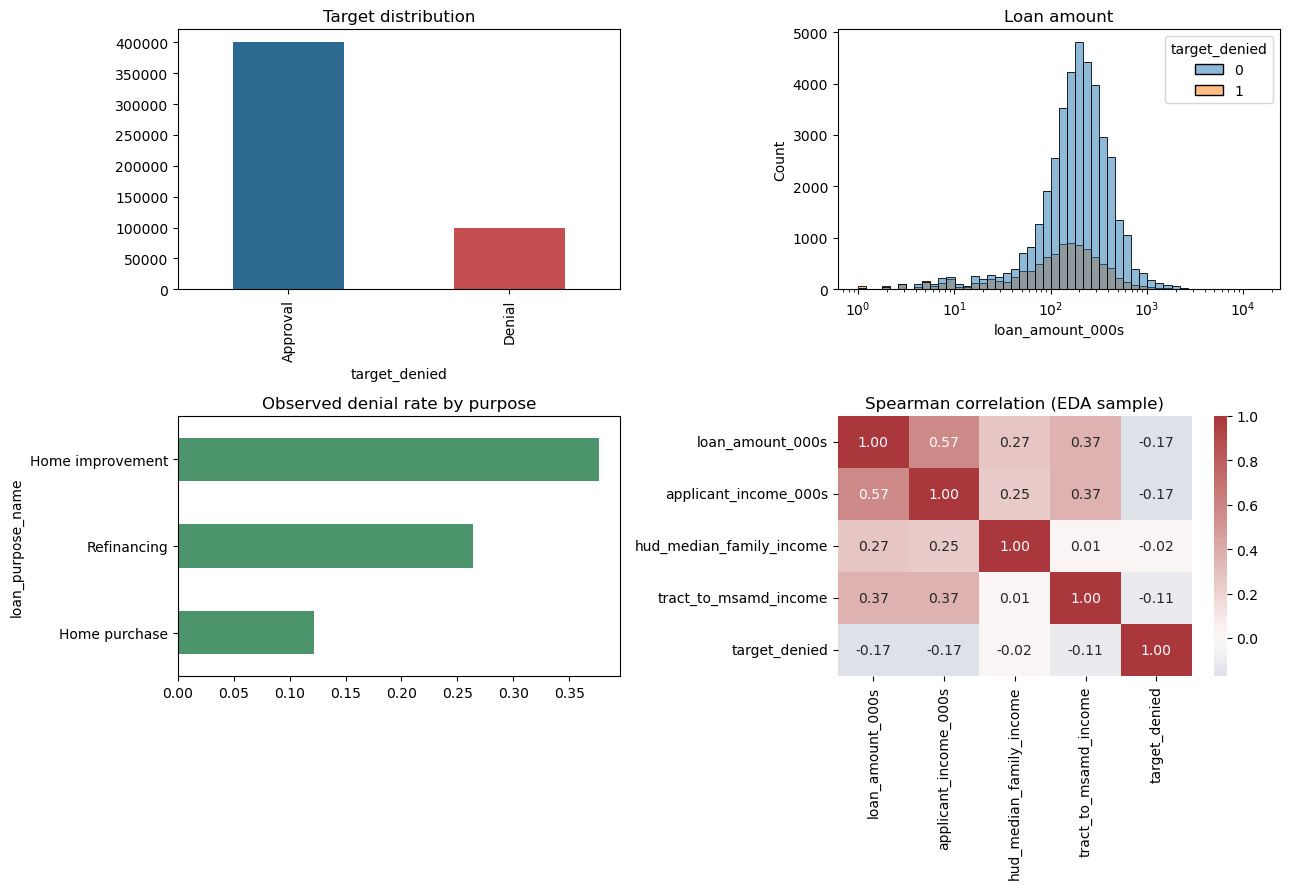

,mean,size
loan_purpose_name,,
Home purchase,0.121344,26973
Refinancing,0.263615,18197
Home improvement,0.376605,4830


In [4]:
eda = modeling.sample(n=min(50_000,len(modeling)), random_state=SEED)
fig, axes = plt.subplots(2,2,figsize=(13,9))
modeling[TARGET].value_counts().sort_index().rename({0:"Approval",1:"Denial"}).plot.bar(ax=axes[0,0], color=["#2d6a91","#c44e52"], title="Target distribution")
sns.histplot(data=eda, x="loan_amount_000s", hue=TARGET, bins=50, log_scale=(True,False), ax=axes[0,1]); axes[0,1].set_title("Loan amount")
purpose = eda.groupby("loan_purpose_name", observed=False)[TARGET].agg(["mean","size"]).sort_values("mean")
purpose["mean"].plot.barh(ax=axes[1,0], color="#4c956c", title="Observed denial rate by purpose")
numeric = ["loan_amount_000s","applicant_income_000s","hud_median_family_income","tract_to_msamd_income"]
sns.heatmap(eda[numeric+[TARGET]].astype(float).corr(method="spearman"), cmap="vlag", center=0, annot=True, fmt=".2f", ax=axes[1,1])
axes[1,1].set_title("Spearman correlation (EDA sample)"); plt.tight_layout()
plt.savefig(FIGURES/"eda_overview.png", dpi=140); plt.show()
display(purpose)

## 5) Split قبل از هر یادگیری

چون ستون زمان/سال موجود نیست، split تصادفی stratified با seed ثابت 60/20/20 بازسازی می‌شود. Validation و Test هرگز resample نمی‌شوند. Test index ساخته می‌شود، اما در اجرای ذخیره‌شده برای انتخاب یا ارزیابی خوانده نمی‌شود.

In [5]:
all_idx=modeling.index.to_numpy(np.int64); all_y=modeling[TARGET].to_numpy(np.int8)
train_idx, hold_idx, _, hold_y = train_test_split(all_idx, all_y, train_size=.60, test_size=.40,
    stratify=all_y, random_state=SEED, shuffle=True)
val_idx, test_idx = train_test_split(hold_idx, train_size=.50, test_size=.50,
    stratify=hold_y, random_state=SEED, shuffle=True)
train_idx, val_idx, test_idx = map(np.sort,(train_idx,val_idx,test_idx))
assert not (set(train_idx)&set(val_idx) or set(train_idx)&set(test_idx) or set(val_idx)&set(test_idx))
assert set(train_idx)|set(val_idx)|set(test_idx)==set(modeling.index)
def index_hash(x): return hashlib.sha256(np.asarray(x,dtype="<i8").tobytes()).hexdigest()
split_table=pd.DataFrame({"rows":[len(train_idx),len(val_idx),len(test_idx)],
 "denial_rate":[modeling.loc[x,TARGET].mean() for x in (train_idx,val_idx,test_idx)],
 "sha256":[index_hash(x) for x in (train_idx,val_idx,test_idx)]}, index=["train","validation","test"])
display(split_table)

,rows,denial_rate,sha256
train,299844,0.197506,264d4c8a8d7e8be8c0d6d42fcba9fa1dd7cde5689fd7ff...
validation,99948,0.197503,ff11002a277a00a0b3158c3c7cf1c57eb83dc5ad7b2f10...
test,99948,0.197503,25cd7a9518ebadf1ff1e8c567738d9d5479fdf63861fcf...


## 6) مهندسی ویژگی V2 به‌صورت inline

ابتدا ۹ ویژگی عددی مالی و ۷ متغیر categorical مجاز ساخته می‌شوند. سپس فقط خانوادهٔ تأییدشدهٔ V2 یعنی تعامل `Numeric × One-Hot level` اضافه می‌شود. vocabulary دسته‌ها، medianها، scaler و imputer فقط از Train یاد گرفته می‌شوند. خروجی مورد انتظار ۶۶ ستون encoded است.

In [6]:
SOURCE_NUMERIC=("loan_amount_000s","applicant_income_000s","hud_median_family_income","tract_to_msamd_income")
CATEGORICAL=("agency_name","loan_type_name","property_type_name","loan_purpose_name","owner_occupancy_name","preapproval_name","lien_status_name")
MODEL_NUMERIC=("loan_amount_000s","applicant_income_000s","loan_to_income","log1p_loan_amount_000s",
 "log1p_applicant_income_000s","tract_to_msamd_income_ratio","applicant_income_to_area_median",
 "applicant_income_zero","hud_median_family_income_zero")
ONEHOT_NUMERIC_PAIRS=(("loan_type_name","loan_amount_000s"),("loan_type_name","loan_to_income"),
 ("property_type_name","loan_amount_000s"),("property_type_name","loan_to_income"),
 ("loan_purpose_name","loan_amount_000s"),("loan_purpose_name","loan_to_income"),
 ("owner_occupancy_name","applicant_income_000s"),("owner_occupancy_name","loan_to_income"),
 ("preapproval_name","loan_amount_000s"),("lien_status_name","loan_amount_000s"),("lien_status_name","loan_to_income"))

def safe_numeric(s): return pd.to_numeric(s,errors="coerce").astype("float64").mask(lambda z:z<0)
def safe_ratio(a,b):
    av=a.to_numpy(float,na_value=np.nan); bv=b.to_numpy(float,na_value=np.nan); out=np.full(av.shape,np.nan)
    valid=np.isfinite(av)&np.isfinite(bv)&(bv>0); np.divide(av,bv,out=out,where=valid)
    return pd.Series(out,index=a.index,dtype="float64")
def slug(value):
    import re
    readable=re.sub(r"[^a-z0-9]+","_",str(value).lower()).strip("_")[:28] or "level"
    return f"{readable}_{hashlib.sha1(str(value).encode()).hexdigest()[:6]}"

class FinancialFeatureEngineer(BaseEstimator,TransformerMixin):
    def fit(self,X,y=None):
        missing=sorted(set(SOURCE_NUMERIC+CATEGORICAL)-set(X.columns))
        if missing: raise ValueError(f"missing required columns: {missing}")
        self.output_features_=np.asarray(MODEL_NUMERIC+CATEGORICAL,dtype=object); return self
    def transform(self,X):
        check_is_fitted(self,"output_features_"); n={c:safe_numeric(X[c]) for c in SOURCE_NUMERIC}
        loan,income=n["loan_amount_000s"],n["applicant_income_000s"]; area=n["hud_median_family_income"]/1000
        out=pd.DataFrame(index=X.index); out["loan_amount_000s"]=loan; out["applicant_income_000s"]=income
        out["loan_to_income"]=safe_ratio(loan,income); out["log1p_loan_amount_000s"]=np.log1p(loan)
        out["log1p_applicant_income_000s"]=np.log1p(income); out["tract_to_msamd_income_ratio"]=n["tract_to_msamd_income"]/100
        out["applicant_income_to_area_median"]=safe_ratio(income,area)
        out["applicant_income_zero"]=income.eq(0).astype(float); out["hud_median_family_income_zero"]=n["hud_median_family_income"].eq(0).astype(float)
        for c in CATEGORICAL: out[c]=X[c].astype("object")
        return out.loc[:,self.output_features_]

class SelectedV2FeatureEngineer(BaseEstimator,TransformerMixin):
    def fit(self,X,y=None):
        self.base_=FinancialFeatureEngineer().fit(X); frame=self.base_.transform(X); self.levels_={}
        for category,_ in ONEHOT_NUMERIC_PAIRS:
            if category not in self.levels_: self.levels_[category]=tuple(sorted(frame[category].astype("string").fillna("__MISSING__").unique()))
        transformed=self._make(frame); self.output_features_=np.asarray(transformed.columns,dtype=object); return self
    def _make(self,frame):
        out={c:frame[c].copy() for c in MODEL_NUMERIC}
        for category,numeric in ONEHOT_NUMERIC_PAIRS:
            keys=frame[category].astype("string").fillna("__MISSING__"); values=frame[numeric].astype(float)
            for level in self.levels_[category]: out[f"{numeric}__x__{category}__{slug(level)}"]=np.where(keys.eq(level),values,0.0)
        for c in CATEGORICAL: out[c]=frame[c].astype("object")
        return pd.DataFrame(out,index=frame.index)
    def transform(self,X):
        check_is_fitted(self,"output_features_"); out=self._make(self.base_.transform(X)); return out.loc[:,self.output_features_]

def build_v2_pipeline():
    onehot=OneHotEncoder(handle_unknown="ignore",sparse_output=True,dtype=np.float64)
    num=Pipeline([("impute",SimpleImputer(strategy="median",add_indicator=True,keep_empty_features=True)),("scale",StandardScaler())])
    cat=Pipeline([("impute",SimpleImputer(strategy="most_frequent")),("onehot",onehot)])
    prep=ColumnTransformer([("numeric",num,make_column_selector(dtype_include=np.number)),
                            ("categorical",cat,make_column_selector(dtype_exclude=np.number))],sparse_threshold=1.0)
    return Pipeline([("feature_v2",SelectedV2FeatureEngineer()),("preprocess",prep)])

In [7]:
# fit فقط روی نمونهٔ Train original-weighted
def stratified_cap(indices, cap, seed=SEED):
    indices=np.asarray(indices,np.int64)
    if cap is None or len(indices)<=cap: return np.sort(indices)
    selected,_=train_test_split(indices,train_size=cap,stratify=modeling.loc[indices,TARGET],random_state=seed,shuffle=True)
    return np.sort(selected)

fit_idx=stratified_cap(train_idx,TRAIN_CAP)
raw_features=modeling.drop(columns=[RAW_TARGET,TARGET])
feature_pipeline=build_v2_pipeline()
X_train_original=feature_pipeline.fit_transform(raw_features.loc[fit_idx])
y_train_original=modeling.loc[fit_idx,TARGET].to_numpy(np.int8)
val_eval_idx=stratified_cap(val_idx,VALIDATION_CAP) if VALIDATION_CAP else val_idx
X_validation=feature_pipeline.transform(raw_features.loc[val_eval_idx]); y_validation=modeling.loc[val_eval_idx,TARGET].to_numpy(np.int8)
names=feature_pipeline.named_steps["preprocess"].get_feature_names_out()
assert X_train_original.shape[1]==66, X_train_original.shape
print({"train":X_train_original.shape,"validation":X_validation.shape,"encoded_features":len(names),"finite":bool(np.isfinite(X_train_original.data).all())})

{'train': (5000, 66), 'validation': (10000, 66), 'encoded_features': 66, 'finite': True}


## 7) Mutual Information ویژگی‌های پایه و جدید

MI فقط روی Train محاسبه می‌شود. این معیار تک‌متغیره است و به‌تنهایی برای انتخاب نهایی کافی نیست؛ انتخاب V2 در پروژه با OOF چندمدلی و چندseed تأیید شده بود.

In [8]:
mi_rows=min(5_000,X_train_original.shape[0]); rng=np.random.default_rng(SEED); pos=np.sort(rng.choice(X_train_original.shape[0],mi_rows,replace=False))
mi_matrix=X_train_original[pos].toarray() if sparse.issparse(X_train_original) else np.asarray(X_train_original[pos])
mi=mutual_info_classif(mi_matrix,y_train_original[pos],discrete_features=False,random_state=SEED)
mi_table=pd.DataFrame({"feature":names,"mutual_information":mi,"kind":["interaction" if "__x__" in n else "base_encoded" for n in names]}).sort_values("mutual_information",ascending=False)
mi_table.to_csv(OUTPUT/"mutual_information_smoke.csv",index=False); display(mi_table.head(20))

,feature,mutual_information,kind
22,numeric__loan_amount_000s__x__loan_purpose_nam...,0.040315,interaction
6,numeric__applicant_income_to_area_median,0.029966,base_encoded
25,numeric__loan_to_income__x__loan_purpose_name_...,0.028841,interaction
33,numeric__loan_amount_000s__x__preapproval_name...,0.027145,interaction
20,numeric__loan_to_income__x__property_type_name...,0.026436,interaction
9,numeric__loan_amount_000s__x__loan_type_name__...,0.025001,interaction
4,numeric__log1p_applicant_income_000s,0.021420,base_encoded
55,categorical__loan_purpose_name_Home purchase,0.021401,base_encoded
40,numeric__loan_to_income__x__lien_status_name__...,0.021302,interaction
32,numeric__loan_to_income__x__owner_occupancy_na...,0.021149,interaction


## 8) سه راهبرد عدم‌توازن — فقط Train

`original_weighted` از وزن balanced استفاده می‌کند؛ oversampling و undersampling فقط indexهای Train را تغییر می‌دهند. Validation و Test هرگز resample نمی‌شوند.

In [9]:
def make_variants(base_indices):
    base=np.asarray(base_indices,np.int64); y=modeling.loc[base,TARGET].to_numpy(np.int8); dummy=np.zeros((len(base),1))
    over_pos,_=RandomOverSampler(random_state=SEED).fit_resample(np.arange(len(base)).reshape(-1,1),y)
    under_pos,_=RandomUnderSampler(random_state=SEED).fit_resample(np.arange(len(base)).reshape(-1,1),y)
    over=base[over_pos.ravel()]; under=base[under_pos.ravel()]
    return {"original_weighted":base,"oversampled":over,"undersampled":under}

variant_indices=make_variants(fit_idx)
variant_data={}
for variant,idx in variant_indices.items():
    X=feature_pipeline.transform(raw_features.loc[idx]); y=modeling.loc[idx,TARGET].to_numpy(np.int8)
    weights=None
    if variant=="original_weighted":
        classes=np.array([0,1]); cw=compute_class_weight("balanced",classes=classes,y=y); weights=np.where(y==0,cw[0],cw[1])
    variant_data[variant]=(X,y,weights,idx)
variant_summary=pd.DataFrame([{"variant":k,"rows":len(v[1]),"unique_source_rows":len(np.unique(v[3])),"denial_rate":v[1].mean()} for k,v in variant_data.items()])
display(variant_summary)

,variant,rows,unique_source_rows,denial_rate
0,original_weighted,5000,5000,0.1976
1,oversampled,8024,5000,0.5000
2,undersampled,1976,1976,0.5000


## 9) معیارها و جست‌وجوی threshold

از GridSearchCV برای threshold استفاده نمی‌شود، چون threshold پارامتر estimator نیست. یک grid قطعی شامل ۱۹۹ quantile روی Validation، MCC را با tie-break کوچک Balanced Accuracy بیشینه می‌کند.

In [10]:
def evaluate_binary(y,p,threshold=.5):
    y=np.asarray(y,np.int8); p=np.asarray(p,float); pred=(p>=threshold).astype(np.int8); tn,fp,fn,tp=confusion_matrix(y,pred,labels=[0,1]).ravel()
    div=lambda a,b:float(a/b) if b else 0.; clipped=np.clip(p,1e-7,1-1e-7)
    return {"threshold":float(threshold),"accuracy":accuracy_score(y,pred),"balanced_accuracy":balanced_accuracy_score(y,pred),
      "f1_denial":f1_score(y,pred,zero_division=0),"mcc":matthews_corrcoef(y,pred),"roc_auc":roc_auc_score(y,p),
      "pr_auc":average_precision_score(y,p),"log_loss":log_loss(y,clipped,labels=[0,1]),"brier_score":brier_score_loss(y,p),
      "recall_denial":div(tp,tp+fn),"precision_denial":div(tp,tp+fp),"tn":int(tn),"fp":int(fp),"fn":int(fn),"tp":int(tp),
      "degenerate":bool(np.unique(pred).size<2 or div(tp,tp+fn)<.01)}
def optimize_threshold(y,p,grid_size=199):
    candidates=np.unique(np.r_[.5,np.quantile(p,np.linspace(.005,.995,grid_size))]); candidates=candidates[(candidates>0)&(candidates<1)]
    best=None
    for t in candidates:
        m=evaluate_binary(y,p,t); score=m["mcc"]+1e-3*m["balanced_accuracy"]
        if best is None or score>best[0]: best=(score,t,m)
    return best[1],best[2]
def denial_probability(model,X):
    classes=list(model.classes_); return model.predict_proba(X)[:,classes.index(1)]

## 10) تنظیمات دقیق مدل‌های کلاسیک V2

دیکشنری زیر تنظیمات production را ثبت می‌کند. در smoke فقط تعداد tree/iteration با `TREE_SCALE` کاهش می‌یابد؛ سایر پارامترها یکسان‌اند.

In [11]:
PRODUCTION_CLASSICAL={
 "dummy":{"strategy":"stratified"},
 "logistic_regression":{"solver":"saga","C":1.0,"max_iter":500,"tol":1e-3},
 "random_forest":{"n_estimators":180,"min_samples_leaf":3,"max_features":"sqrt"},
 "extra_trees":{"n_estimators":180,"min_samples_leaf":3,"max_features":"sqrt"},
 "xgboost":{"n_estimators":250,"max_depth":6,"learning_rate":.08,"subsample":.85,"colsample_bytree":.85,"min_child_weight":3,"reg_lambda":1.0},
 "lightgbm":{"n_estimators":250,"learning_rate":.06,"num_leaves":31,"min_child_samples":30,"subsample":.85,"colsample_bytree":.85,"reg_lambda":1.0},
 "catboost":{"iterations":250,"depth":7,"learning_rate":.08},
 "bagging":{"n_estimators":80,"base_max_depth":10,"base_min_samples_leaf":5,"max_samples":.8,"max_features":.9},
 "stacking":{"extra_n_estimators":100,"extra_min_samples_leaf":4,"lgbm_n_estimators":140,"lgbm_learning_rate":.07,"lgbm_num_leaves":25,"final_C":1.0}}
display(pd.DataFrame({k:[json.dumps(v)] for k,v in PRODUCTION_CLASSICAL.items()}).T.rename(columns={0:"production_parameters"}))

def scaled(n): return max(12,int(round(n*TREE_SCALE)))
def make_classical(name,variant):
    n_jobs=8
    if name=="dummy": return DummyClassifier(strategy="stratified",random_state=SEED)
    if name=="logistic_regression": return LogisticRegression(solver="saga",C=1,max_iter=500,tol=1e-3,random_state=SEED,n_jobs=n_jobs)
    if name=="random_forest": return RandomForestClassifier(n_estimators=scaled(180),min_samples_leaf=3,max_features="sqrt",n_jobs=n_jobs,random_state=SEED)
    if name=="extra_trees": return ExtraTreesClassifier(n_estimators=scaled(180),min_samples_leaf=3,max_features="sqrt",n_jobs=n_jobs,random_state=SEED)
    if name=="xgboost":
        from xgboost import XGBClassifier
        return XGBClassifier(n_estimators=scaled(250),max_depth=6,learning_rate=.08,subsample=.85,colsample_bytree=.85,min_child_weight=3,reg_lambda=1,tree_method="hist",eval_metric="logloss",n_jobs=n_jobs,random_state=SEED)
    if name=="lightgbm":
        from lightgbm import LGBMClassifier
        return LGBMClassifier(n_estimators=scaled(250),learning_rate=.06,num_leaves=31,min_child_samples=30,subsample=.85,colsample_bytree=.85,reg_lambda=1,n_jobs=n_jobs,random_state=SEED,verbosity=-1)
    if name=="catboost":
        from catboost import CatBoostClassifier
        return CatBoostClassifier(iterations=scaled(250),depth=7,learning_rate=.08,loss_function="Logloss",eval_metric="AUC",random_seed=SEED,thread_count=n_jobs,verbose=False,allow_writing_files=False)
    if name=="bagging":
        base=DecisionTreeClassifier(max_depth=10,min_samples_leaf=5,random_state=SEED)
        return BaggingClassifier(estimator=base,n_estimators=scaled(80),max_samples=.8,max_features=.9,bootstrap=True,n_jobs=n_jobs,random_state=SEED)
    if name=="stacking":
        from lightgbm import LGBMClassifier
        def bases(fold_local_ros=False):
            raw=[("lr",LogisticRegression(solver="liblinear",C=.8,max_iter=300,random_state=SEED)),
                 ("extra",ExtraTreesClassifier(n_estimators=scaled(100),min_samples_leaf=4,max_features="sqrt",n_jobs=n_jobs,random_state=SEED)),
                 ("lgbm",LGBMClassifier(n_estimators=scaled(140),learning_rate=.07,num_leaves=25,n_jobs=n_jobs,random_state=SEED,verbosity=-1))]
            return [(n,ImbPipeline([("ros",RandomOverSampler(random_state=SEED)),("model",m)])) for n,m in raw] if fold_local_ros else raw
        return StackingClassifier(estimators=bases(variant=="oversampled"),final_estimator=LogisticRegression(solver="liblinear",C=1,max_iter=300,random_state=SEED),stack_method="predict_proba",cv=3,n_jobs=n_jobs)
    raise KeyError(name)

,production_parameters
dummy,"{""strategy"": ""stratified""}"
logistic_regression,"{""solver"": ""saga"", ""C"": 1.0, ""max_iter"": 500, ..."
random_forest,"{""n_estimators"": 180, ""min_samples_leaf"": 3, ""..."
extra_trees,"{""n_estimators"": 180, ""min_samples_leaf"": 3, ""..."
xgboost,"{""n_estimators"": 250, ""max_depth"": 6, ""learnin..."
lightgbm,"{""n_estimators"": 250, ""learning_rate"": 0.06, ""..."
catboost,"{""iterations"": 250, ""depth"": 7, ""learning_rate..."
bagging,"{""n_estimators"": 80, ""base_max_depth"": 10, ""ba..."
stacking,"{""extra_n_estimators"": 100, ""extra_min_samples..."


## 11) اجرای ۲۷ مدل کلاسیک

برای Stacking oversampled، ورودی unique استفاده و RandomOverSampler داخل هر fold قرار داده می‌شود؛ بنابراین clone یک source row هم‌زمان در fit و OOF-held fold ظاهر نمی‌شود.

In [12]:
CLASSICAL=list(PRODUCTION_CLASSICAL); results=[]; probabilities={}; trained={}
for variant in variant_data:
    X,y,w,idx=variant_data[variant]
    for name in CLASSICAL:
        model=make_classical(name,variant)
        fit_X,fit_y,fit_w=X,y,w
        if name=="stacking" and variant=="oversampled": fit_X,fit_y,fit_w=X_train_original,y_train_original,None
        started=time.perf_counter()
        kwargs={"sample_weight":fit_w} if fit_w is not None and name!="stacking" else {}
        model.fit(fit_X,fit_y,**kwargs); runtime=time.perf_counter()-started
        p=denial_probability(model,X_validation); threshold,metrics=optimize_threshold(y_validation,p)
        row={"family":"classical","model":name,"variant":variant,"fit_seconds":runtime,**metrics}
        results.append(row); probabilities[(variant,name)]=p; trained[(variant,name)]=model
        print(variant,name,round(metrics["pr_auc"],4),round(metrics["mcc"],4),round(runtime,2))
classical_results=pd.DataFrame(results); display(classical_results.sort_values(["pr_auc","mcc"],ascending=False).head(12))

original_weighted dummy 0.1982 0.0037 0.0


original_weighted logistic_regression 0.4138 0.2971 0.53


original_weighted random_forest 0.3869 0.2585 0.19


original_weighted extra_trees 0.413 0.2869 0.18


original_weighted xgboost 0.4159 0.2866 0.86


...

undersampled lightgbm 0.3946 0.2666 0.05


undersampled catboost 0.4212 0.2885 0.27


undersampled bagging 0.3768 0.2773 0.09


undersampled stacking 0.4267 0.302 1.27


,family,model,variant,fit_seconds,threshold,accuracy,balanced_accuracy,f1_denial,mcc,roc_auc,pr_auc,log_loss,brier_score,recall_denial,precision_denial,tn,fp,fn,tp,degenerate
8,classical,stacking,original_weighted,2.696912,0.286093,0.7887,0.650006,0.440265,0.310886,0.736899,0.435494,0.438191,0.138194,0.420759,0.461667,7056,969,1144,831,False
17,classical,stacking,oversampled,3.278474,0.243259,0.7253,0.674060,0.458719,0.299661,0.734451,0.431336,0.438931,0.138734,0.589367,0.375484,6089,1936,811,1164,False
26,classical,stacking,undersampled,1.268528,0.596309,0.7577,0.663137,0.452429,0.302018,0.732778,0.426725,0.595915,0.204521,0.506835,0.408571,6576,1449,974,1001,False
6,classical,catboost,original_weighted,0.434495,0.633277,0.7847,0.643697,0.429669,0.297810,0.732124,0.424417,0.568358,0.193201,0.410633,0.450556,7036,989,1164,811,False
24,classical,catboost,undersampled,0.269937,0.568048,0.7313,0.664439,0.448821,0.288544,0.729178,0.421234,0.597634,0.205755,0.553924,0.377241,6219,1806,881,1094,False
15,classical,catboost,oversampled,0.347682,0.607198,0.7733,0.649572,0.436770,0.295003,0.727307,0.420695,0.559720,0.189898,0.445063,0.428780,6854,1171,1096,879,False
5,classical,lightgbm,original_weighted,0.060289,0.533091,0.7365,0.667869,0.453886,0.296096,0.727133,0.419219,0.555403,0.188106,0.554430,0.384211,6270,1755,880,1095,False
4,classical,xgboost,original_weighted,0.860949,0.509921,0.7205,0.666489,0.449261,0.286627,0.726412,0.415906,0.552644,0.186640,0.577215,0.367742,6065,1960,835,1140,False
14,classical,lightgbm,oversampled,0.070052,0.512652,0.7221,0.664241,0.446965,0.284038,0.725100,0.415760,0.548082,0.185189,0.568608,0.368197,6098,1927,852,1123,False
1,classical,logistic_regression,original_weighted,0.533625,0.645306,0.7865,0.641764,0.426846,0.297069,0.724574,0.413757,0.595390,0.204183,0.402532,0.454286,7070,955,1180,795,False


## 12) معماری‌ها و تنظیمات DL به‌صورت inline

چهار خانواده اجرا می‌شوند: MLP، TabNet، FT-Transformer سبک و Modern Hopfield. در پروفایل full همان epoch/patience/batch تولید V2 اعمال می‌شود؛ smoke به سه epoch محدود است.

In [13]:
PRODUCTION_DL={"mlp":{"max_epochs":18,"patience":4,"batch_size":1024,"learning_rate":1e-3},
 "tabnet":{"max_epochs":25,"patience":4,"batch_size":1024,"virtual_batch_size":128,"learning_rate":.02},
 "tabular_transformer":{"max_epochs":10,"patience":3,"batch_size":512,"learning_rate":1e-3},
 "modern_hopfield":{"max_epochs":16,"patience":4,"batch_size":1024,"learning_rate":1e-3}}
display(pd.DataFrame(PRODUCTION_DL).T)

class TabularMLP(nn.Module):
    def __init__(self,d): super().__init__(); self.net=nn.Sequential(nn.Linear(d,128),nn.BatchNorm1d(128),nn.ReLU(),nn.Dropout(.2),nn.Linear(128,64),nn.BatchNorm1d(64),nn.ReLU(),nn.Dropout(.2),nn.Linear(64,1))
    def forward(self,x): return self.net(x).squeeze(-1)
class Tokenizer(nn.Module):
    def __init__(self,n,d): super().__init__(); self.w=nn.Parameter(torch.empty(n,d)); self.b=nn.Parameter(torch.zeros(n,d)); nn.init.xavier_uniform_(self.w)
    def forward(self,x): return x.unsqueeze(-1)*self.w.unsqueeze(0)+self.b.unsqueeze(0)
class TabularTransformer(nn.Module):
    def __init__(self,d):
        super().__init__(); td=16; self.tok=Tokenizer(d,td); self.cls=nn.Parameter(torch.zeros(1,1,td)); layer=nn.TransformerEncoderLayer(td,4,td*4,.1,activation="gelu",batch_first=True,norm_first=True); self.enc=nn.TransformerEncoder(layer,2); self.norm=nn.LayerNorm(td); self.head=nn.Linear(td,1)
    def forward(self,x):
        z=self.tok(x); c=self.cls.expand(x.shape[0],-1,-1); return self.head(self.norm(self.enc(torch.cat((c,z),1))[:,0])).squeeze(-1)
class HopfieldLayer(nn.Module):
    def __init__(self,d,p=32): super().__init__(); self.k=nn.Parameter(torch.empty(p,d)); self.v=nn.Parameter(torch.empty(p,d)); self.beta=1/np.sqrt(d); nn.init.xavier_uniform_(self.k); nn.init.xavier_uniform_(self.v)
    def forward(self,x): return torch.softmax(self.beta*x@self.k.T,-1)@self.v
class ModernHopfield(nn.Module):
    def __init__(self,d): super().__init__(); self.project=nn.Sequential(nn.Linear(d,64),nn.GELU()); self.memory=HopfieldLayer(64); self.norm=nn.LayerNorm(64); self.head=nn.Sequential(nn.Dropout(.15),nn.Linear(64,32),nn.GELU(),nn.Linear(32,1))
    def forward(self,x): z=self.project(x); return self.head(self.norm(z+self.memory(z))).squeeze(-1)
def dense32(X): return np.ascontiguousarray(X.toarray() if sparse.issparse(X) else X,dtype=np.float32)
def neural_probability(model,X,device,batch=2048):
    loader=DataLoader(torch.from_numpy(dense32(X)),batch_size=batch); out=[]; model.eval()
    with torch.no_grad():
        for xb in loader: out.append(torch.sigmoid(model(xb.to(device))).cpu().numpy())
    return np.concatenate(out).astype(float)
def train_torch(model,X,y,Xe,ye,variant,config):
    random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); device="cuda" if torch.cuda.is_available() else "cpu"; model=model.to(device)
    epochs=min(config["max_epochs"],DL_EPOCH_CAP) if DL_EPOCH_CAP else config["max_epochs"]
    loader=DataLoader(TensorDataset(torch.from_numpy(dense32(X)),torch.from_numpy(np.asarray(y,np.float32))),batch_size=config["batch_size"],shuffle=True,generator=torch.Generator().manual_seed(SEED))
    pos=float((y==0).sum()/max((y==1).sum(),1)) if variant=="original_weighted" else 1.; loss_fn=nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos,device=device)); opt=torch.optim.AdamW(model.parameters(),lr=config["learning_rate"],weight_decay=1e-4)
    best=(-1,None); started=time.perf_counter()
    for epoch in range(epochs):
        model.train()
        for xb,yb in loader:
            xb,yb=xb.to(device),yb.to(device); opt.zero_grad(set_to_none=True); loss=loss_fn(model(xb),yb); loss.backward(); nn.utils.clip_grad_norm_(model.parameters(),5); opt.step()
        score=average_precision_score(ye,neural_probability(model,Xe,device))
        if score>best[0]: best=(score,{k:v.detach().cpu().clone() for k,v in model.state_dict().items()})
    model.load_state_dict(best[1]); return model,time.perf_counter()-started,device

,max_epochs,patience,batch_size,learning_rate,virtual_batch_size
mlp,18.0,4.0,1024.0,0.001,NaN
tabnet,25.0,4.0,1024.0,0.020,128.0
tabular_transformer,10.0,3.0,512.0,0.001,NaN
modern_hopfield,16.0,4.0,1024.0,0.001,NaN


## 13) اجرای ۱۲ مدل DL

In [14]:
early_pos=stratified_cap(np.arange(len(y_validation)),min(3000,len(y_validation)))
Xe,ye=X_validation[early_pos],y_validation[early_pos]
for variant,(X,y,w,idx) in variant_data.items():
    for name in PRODUCTION_DL:
        cfg=PRODUCTION_DL[name]; started=time.perf_counter()
        if name=="tabnet":
            from pytorch_tabnet.tab_model import TabNetClassifier
            epochs=min(cfg["max_epochs"],DL_EPOCH_CAP) if DL_EPOCH_CAP else cfg["max_epochs"]
            model=TabNetClassifier(n_d=16,n_a=16,n_steps=3,gamma=1.3,lambda_sparse=1e-4,optimizer_params={"lr":.02},seed=SEED,verbose=0,device_name="cuda" if torch.cuda.is_available() else "cpu")
            weights={0:1.,1:float((y==0).sum()/max((y==1).sum(),1))} if variant=="original_weighted" else 0
            model.fit(dense32(X),y,eval_set=[(dense32(Xe),ye)],eval_name=["validation"],eval_metric=["auc"],max_epochs=epochs,patience=min(cfg["patience"],epochs),batch_size=cfg["batch_size"],virtual_batch_size=cfg["virtual_batch_size"],num_workers=0,weights=weights)
            runtime=time.perf_counter()-started; p=model.predict_proba(dense32(X_validation))[:,1]
        else:
            ctor={"mlp":TabularMLP,"tabular_transformer":TabularTransformer,"modern_hopfield":ModernHopfield}[name]
            model,runtime,device=train_torch(ctor(X.shape[1]),X,y,Xe,ye,variant,cfg); p=neural_probability(model,X_validation,device)
        threshold,metrics=optimize_threshold(y_validation,p); results.append({"family":"dl","model":name,"variant":variant,"fit_seconds":runtime,**metrics}); probabilities[(variant,name)]=p; trained[(variant,name)]=model
        print(variant,name,round(metrics["pr_auc"],4),round(metrics["mcc"],4),round(runtime,2))
        if torch.cuda.is_available(): torch.cuda.empty_cache()
results_df=pd.DataFrame(results); display(results_df[results_df.family=="dl"].sort_values(["pr_auc","mcc"],ascending=False))

original_weighted mlp 0.3912 0.2717 1.09


Stop training because you reached max_epochs = 3 with best_epoch = 1 and best_validation_auc = 0.64112


original_weighted tabnet 0.2658 0.1492 1.29


original_weighted tabular_transformer 0.3885 0.2741 0.77


original_weighted modern_hopfield 0.3697 0.2538 0.13


...

Stop training because you reached max_epochs = 3 with best_epoch = 2 and best_validation_auc = 0.59425


undersampled tabnet 0.2646 0.1337 0.33


undersampled tabular_transformer 0.3497 0.2188 0.4


undersampled modern_hopfield 0.339 0.2148 0.06


,family,model,variant,fit_seconds,threshold,accuracy,balanced_accuracy,f1_denial,mcc,roc_auc,pr_auc,log_loss,brier_score,recall_denial,precision_denial,tn,fp,fn,tp,degenerate
31,dl,mlp,oversampled,0.181784,0.604520,0.7645,0.650006,0.435928,0.288327,0.722828,0.398269,0.622824,0.215114,0.460759,0.413636,6735,1290,1065,910,False
33,dl,tabular_transformer,oversampled,0.952950,0.667231,0.7791,0.639635,0.422484,0.286329,0.719166,0.396412,0.571600,0.194636,0.409114,0.436757,6983,1042,1167,808,False
27,dl,mlp,original_weighted,1.086154,0.568794,0.7567,0.642474,0.424142,0.271663,0.711916,0.391214,0.656235,0.230938,0.453671,0.398222,6671,1354,1079,896,False
29,dl,tabular_transformer,original_weighted,0.766874,0.624117,0.7857,0.626188,0.400559,0.274065,0.716233,0.388494,0.563263,0.189885,0.362532,0.447500,7141,884,1259,716,False
34,dl,modern_hopfield,oversampled,0.180225,0.561915,0.7111,0.661205,0.441739,0.275160,0.720866,0.388366,0.585092,0.201477,0.578734,0.357187,5968,2057,832,1143,False
30,dl,modern_hopfield,original_weighted,0.127158,0.547601,0.7213,0.643894,0.422383,0.253806,0.706999,0.369675,0.597878,0.205561,0.515949,0.357544,6194,1831,956,1019,False
35,dl,mlp,undersampled,0.070585,0.491609,0.7264,0.642491,0.421075,0.254061,0.689194,0.364770,0.656822,0.231553,0.503797,0.361687,6269,1756,980,995,False
37,dl,tabular_transformer,undersampled,0.400478,0.534774,0.6487,0.634351,0.407089,0.218826,0.676378,0.349724,0.691437,0.247296,0.610633,0.305316,5281,2744,769,1206,False
38,dl,modern_hopfield,undersampled,0.061245,0.552447,0.7523,0.606905,0.368917,0.214842,0.671741,0.339037,0.643446,0.225855,0.366582,0.371282,6799,1226,1251,724,False
32,dl,tabnet,oversampled,1.054825,0.529997,0.6741,0.626701,0.399263,0.212219,0.665319,0.330726,0.657077,0.232010,0.548354,0.313913,5658,2367,892,1083,False


## 14) سه Hybrid با انتخاب Validation-only

بهترین ML و DL هر variant با ۴۱ وزن ترکیب می‌شوند. امتیاز انتخاب `PR-AUC + 0.1×MCC` است و Test هیچ نقشی ندارد.

In [15]:
ML=set(PRODUCTION_CLASSICAL)-{"dummy"}; DL=set(PRODUCTION_DL); hybrids=[]
for variant in variant_data:
    subset=pd.DataFrame(results); subset=subset[(subset.variant==variant)&(~subset.degenerate)]
    ml=subset[subset.model.isin(ML)].sort_values(["pr_auc","mcc"],ascending=False).iloc[0]
    dl=subset[subset.model.isin(DL)].sort_values(["pr_auc","mcc"],ascending=False).iloc[0]
    best=None
    for weight in np.linspace(0,1,41):
        p=weight*probabilities[(variant,ml.model)]+(1-weight)*probabilities[(variant,dl.model)]
        threshold,metrics=optimize_threshold(y_validation,p); score=metrics["pr_auc"]+.1*metrics["mcc"]
        if best is None or score>best[0]: best=(score,weight,p,threshold,metrics)
    _,weight,p,threshold,metrics=best; row={"family":"hybrid","model":"hybrid_ml_dl","variant":variant,"ml":ml.model,"dl":dl.model,"ml_weight":weight,"fit_seconds":0.,**metrics}
    results.append(row); probabilities[(variant,"hybrid_ml_dl")]=p; hybrids.append(row)
display(pd.DataFrame(hybrids).sort_values(["pr_auc","mcc"],ascending=False))

,family,model,variant,ml,dl,ml_weight,fit_seconds,threshold,accuracy,balanced_accuracy,...,pr_auc,log_loss,brier_score,recall_denial,precision_denial,tn,fp,fn,tp,degenerate
0,hybrid,hybrid_ml_dl,original_weighted,stacking,mlp,1.000,0.0,0.286093,0.7887,0.650006,...,0.435494,0.438191,0.138194,0.420759,0.461667,7056,969,1144,831,False
1,hybrid,hybrid_ml_dl,oversampled,stacking,mlp,0.975,0.0,0.302923,0.7661,0.657301,...,0.431348,0.439097,0.138776,0.477468,0.419111,6718,1307,1032,943,False
2,hybrid,hybrid_ml_dl,undersampled,stacking,mlp,0.975,0.0,0.586647,0.7529,0.665109,...,0.426842,0.596225,0.204587,0.520000,0.402745,6502,1523,948,1027,False


## 15) Calibration و انتخاب finalist بدون Test

Validation به دو نیمهٔ stratified تقسیم می‌شود: نیمهٔ اول برای fit calibration و نیمهٔ دوم برای انتخاب روش و threshold. این ساختار همان منطق نهایی پروژه است.

In [16]:
all_results=pd.DataFrame(results); all_results.to_csv(OUTPUT/"notebook_validation_results.csv",index=False)
winner=all_results[~all_results.degenerate].sort_values(["pr_auc","mcc"],ascending=False).iloc[0]
p=probabilities[(winner.variant,winner.model)]; positions=np.arange(len(y_validation)); cal_pos,sel_pos=train_test_split(positions,train_size=.5,stratify=y_validation,random_state=SEED)
calibrators={"none":None,"sigmoid":LogisticRegression(solver="lbfgs",random_state=SEED).fit(p[cal_pos,None],y_validation[cal_pos]),"isotonic":IsotonicRegression(out_of_bounds="clip",y_min=0,y_max=1).fit(p[cal_pos],y_validation[cal_pos])}
def calibrated(cal,x): return x if cal is None else (cal.predict_proba(x[:,None])[:,1] if hasattr(cal,"predict_proba") else cal.predict(x))
scores={}
for name,cal in calibrators.items():
    cp=np.clip(calibrated(cal,p[sel_pos]),1e-7,1-1e-7); scores[name]={"brier":brier_score_loss(y_validation[sel_pos],cp),"log_loss":log_loss(y_validation[sel_pos],cp)}
    scores[name]["objective"]=scores[name]["brier"]+.1*scores[name]["log_loss"]
best_cal=min(scores,key=lambda k:scores[k]["objective"]); final_threshold,final_val_metrics=optimize_threshold(y_validation[sel_pos],calibrated(calibrators[best_cal],p[sel_pos]))
print("validation winner",winner[["model","variant","pr_auc","mcc"]].to_dict()); print("calibration",best_cal,"threshold",final_threshold); display(pd.DataFrame(scores).T)

validation winner {'model': 'stacking', 'variant': 'original_weighted', 'pr_auc': 0.43549393163407324, 'mcc': 0.31088607654461686}
calibration none threshold 0.2968910273719512


,brier,log_loss,objective
none,0.136248,0.433219,0.179569
sigmoid,0.137156,0.437058,0.180861
isotonic,0.136086,0.439821,0.180068


## 16) نتایج واقعی نسل frozen V2

جدول زیر نتیجهٔ اجرای production 60k ثبت‌شده است و با smoke جاری مخلوط نمی‌شود. Hybrid و CatBoost منفرد تقریباً هم‌سطح‌اند؛ Hybrid بالاترین PR-AUC و CatBoost گزینهٔ ساده‌تر است.

In [17]:
frozen_v2=pd.DataFrame([
 {"candidate":"predictive_hybrid","model":"CatBoost + Modern Hopfield","variant":"undersampled","pr_auc":.462068642391656,"roc_auc":.7493828242617824,"mcc":.31956061520813916,"balanced_accuracy":.6694282024790257,"accuracy":.7695101452755433,"denial_recall":.5040020263424518},
 {"candidate":"single","model":"CatBoost","variant":"undersampled","pr_auc":.4620286807813392,"roc_auc":.748943986769152,"mcc":.3194560180131036,"balanced_accuracy":.6689479844804724,"accuracy":.7702105094649218,"denial_recall":.5015704154002026},
 {"candidate":"practical","model":"LightGBM","variant":"oversampled","pr_auc":.4578207602232684,"roc_auc":.7453922312751791,"mcc":.3163752311564581,"balanced_accuracy":.6676711674266966,"accuracy":.7685596510185296,"denial_recall":.5009118541033435}])
display(frozen_v2)

,candidate,model,variant,pr_auc,roc_auc,mcc,balanced_accuracy,accuracy,denial_recall
0,predictive_hybrid,CatBoost + Modern Hopfield,undersampled,0.462069,0.749383,0.319561,0.669428,0.769510,0.504002
1,single,CatBoost,undersampled,0.462029,0.748944,0.319456,0.668948,0.770211,0.501570
2,practical,LightGBM,oversampled,0.457821,0.745392,0.316375,0.667671,0.768560,0.500912


## 17) Serialization و reload در محیط notebook

به‌عنوان تست مسیر serialization، بهترین مدل کلاسیک smoke همراه با pipeline و metadata ذخیره و دوباره بارگذاری می‌شود. فایل‌های frozen اصلی overwrite نمی‌شوند.

In [18]:
best_single=all_results[(all_results.family=="classical")&(all_results.model!="dummy")].sort_values(["pr_auc","mcc"],ascending=False).iloc[0]
bundle={"preprocessor":feature_pipeline,"model":trained[(best_single.variant,best_single.model)],"threshold":float(best_single.threshold),"target":"1=denial","profile":PROFILE,"metrics":best_single.to_dict()}
bundle_path=OUTPUT/"best_classical_smoke_bundle.joblib"; joblib.dump(bundle,bundle_path); reloaded=joblib.load(bundle_path)
probe=raw_features.loc[val_eval_idx[:32]]; probe_p=denial_probability(reloaded["model"],reloaded["preprocessor"].transform(probe))
assert np.isfinite(probe_p).all() and len(probe_p)==32
print({"saved":str(bundle_path),"bytes":bundle_path.stat().st_size,"reload_rows":len(probe_p),"probability_range":[float(probe_p.min()),float(probe_p.max())]})

## 18) Test gate

کد زیر مسیر ارزیابی نهایی را نشان می‌دهد، اما برای نسل frozen اجرا نمی‌شود. Test فقط در یک نسل جدید و پس از قفل‌شدن انتخاب Validation باید فعال شود.

In [19]:
if ALLOW_TEST_ACCESS:
    raise RuntimeError("برای این پروژه Test نسل frozen نباید دوباره باز شود؛ یک generation/split جدید بسازید.")
else:
    print("Test access skipped by design. All notebook model selection used Train/Validation only.")

Test access skipped by design. All notebook model selection used Train/Validation only.


## جمع‌بندی

- تمام منطق اجرایی در همین notebook قرار دارد و هیچ ماژول محلی پروژه import نشده است.
- اجرای smoke همهٔ ۴۲ مدل و سه hybrid را پوشش می‌دهد؛ پروفایل full همان مسیر را در cap=60k اجرا می‌کند.
- V2 از ۳۳ ستون پایه به ۶۶ ستون encoded رسیده است؛ ۳۳ interaction جدید از One-Hot×Numeric ساخته شده‌اند.
- MI فقط روی Train است، sampler فقط روی Train است، و threshold/calibration فقط روی Validation هستند.
- برای استفاده عملیاتی همچنان artifact قفل‌شدهٔ V2 توصیه می‌شود؛ خروجی notebook در مسیر جداگانه نوشته می‌شود.